# Tracking wildfire smoke with AirNow and ACT

Canadian wildfire smoke routinely degrades air quality across the US Midwest and Great Lakes. This notebook reconstructs one such event using the **Atmospheric data Community Toolkit (ACT)** as the sole data source, pulling surface PM$_{2.5}$ from the US EPA **AirNow** API and plotting it entirely with ACT's own display classes.

Because AirNow also re-serves Canadian provincial monitors (for example the Ontario Ministry of the Environment network), a single API path covers stations on **both sides of the border**.

**What we build**
1. A regional map of the latest hourly surface PM$_{2.5}$ at every AirNow station (`GeographicPlotDisplay`).
2. 24-hour PM$_{2.5}$ time series for one site each in Duluth MN, Toronto ON, and Chicago IL (`TimeSeriesDisplay`), on a shared y-axis.

**Before you run**
- Get a free AirNow token at <https://docs.airnowapi.org/> and set it in the `AIRNOW_API` environment variable. The notebook never hard-codes it.
- The date window is pinned to a July 2026 episode so the notebook is reproducible; AirNow serves this range from its rolling archive.

*Authors: Scott Collis; Claude (Anthropic).*

In [ ]:
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import act

print("ACT version:", act.__version__)

ACT version: 2.3.4


## 1. Configuration

The token comes from the environment, and the date window is fixed (UTC, `YYYY-MM-DDTHH` as AirNow expects) rather than derived from the current time, so the notebook always pulls the same episode.

In [ ]:
# Free token from https://docs.airnowapi.org/ -- read from the environment, never hard-coded.
token = os.getenv("AIRNOW_API")
assert token, "Set the AIRNOW_API environment variable to your AirNow token first."

# Fixed date window (UTC). Pinned for reproducibility.
START_DATE = "2026-07-14T15"
END_DATE = "2026-07-15T16"

PM25_MAX = 250.0  # colorbar ceiling for the map (ug/m^3)

## 2. Pull the regional station field through ACT

`act.discovery.get_airnow_bounded_obs` returns a tidy `(time, sites)` `xarray.Dataset`. `data_type='B'` gives both AQI and concentrations; `mon_type=2` includes permanent and mobile monitors. Missing values are flagged as `-999`.

In [ ]:
map_bounds = "-104,40,-74,50"
ds_map = act.discovery.get_airnow_bounded_obs(
    token, START_DATE, END_DATE, map_bounds, "PM25", mon_type=2, data_type="B"
)
print(ds_map)

<xarray.Dataset> Size: 256kB
Dimensions:            (sites: 283, time: 26)
Coordinates:
  * sites              (sites) object 2kB 'SBHS' ... 'Kokomo - E. Vaile Ave.'
  * time               (time) datetime64[us] 208B 2026-07-14T15:00:00 ... 202...
Data variables:
    latitude           (sites) float64 2kB 41.88 46.95 43.56 ... 41.66 40.48
    longitude          (sites) float64 2kB -103.7 -103.5 ... -85.97 -86.11
    aqs_id             (sites) <U12 14kB '840311570004' ... '180670004'
    PM2.5              (time, sites) float64 59kB 4.8 7.2 9.4 ... 26.9 nan nan
    AQI                (time, sites) float64 59kB 27.0 40.0 52.0 ... nan nan
    category           (time, sites) float64 59kB 1.0 1.0 2.0 ... 2.0 nan nan
    raw_concentration  (time, sites) float64 59kB 5.0 8.0 10.8 ... nan nan


Reduce the time series to the **latest valid PM$_{2.5}$ per site** so the map shows a single snapshot.

In [ ]:
pm = ds_map["PM2.5"].values.copy()
pm[pm < 0] = np.nan  # AirNow uses -999 for missing

latest = np.array([
    col[np.where(~np.isnan(col))[0][-1]] if np.any(~np.isnan(col)) else np.nan
    for col in pm.T
])

ds_latest = xr.Dataset(
    {"PM2.5": ("sites", latest)},
    coords={
        "latitude": ("sites", ds_map["latitude"].values),
        "longitude": ("sites", ds_map["longitude"].values),
    },
)
ds_latest["PM2.5"].attrs = {"long_name": "PM2.5", "units": "ug/m^3"}

n_valid = int(np.isfinite(latest).sum())
print(f"{n_valid} stations with a valid latest PM2.5; "
      f"range {np.nanmin(latest):.1f}-{np.nanmax(latest):.1f} ug/m^3")

283 stations with a valid latest PM2.5; range 1.5-547.5 ug/m^3


## 3. Map the station field with ACT's `GeographicPlotDisplay`

Passing an explicit `title` avoids the display's default time-based title (the reduced dataset has no time dimension). The hazardous cluster (dark red, >250 ug/m^3) sits over Lake Superior near Duluth and trails into southern Ontario.

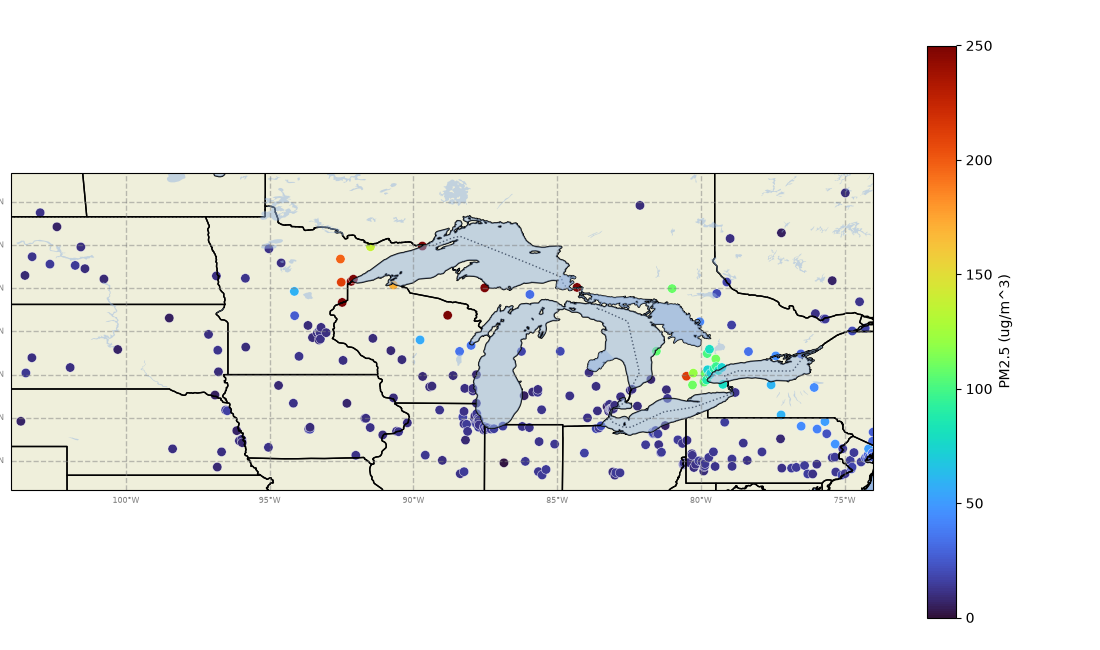

In [ ]:
geo = act.plotting.GeographicPlotDisplay(ds_latest, figsize=(11, 6.5))
geo.geoplot(
    "PM2.5", lat_field="latitude", lon_field="longitude",
    projection=ccrs.PlateCarree(),
    cartopy_feature=["LAND", "OCEAN", "LAKES", "STATES", "BORDERS"],
    title="US + Canada surface PM2.5 via AirNow (data pulled with ACT)",
    cmap="turbo", vmin=0, vmax=PM25_MAX,
    marker="o", s=45, edgecolor="white", linewidth=0.3,
)
plt.gca().set_extent([-104, -74, 39.5, 50.5], crs=ccrs.PlateCarree())
plt.show()

## 4. City time series with ACT's `TimeSeriesDisplay`

Pull a tight bounding box around one representative site in each of three cities, then plot the 24-hour PM$_{2.5}$ series on a **shared y-axis** (`y_rng=(0, 600)`) so the magnitudes are directly comparable: Duluth spikes past 500 ug/m^3 overnight, Toronto climbs to ~110, and Chicago stays near the baseline.

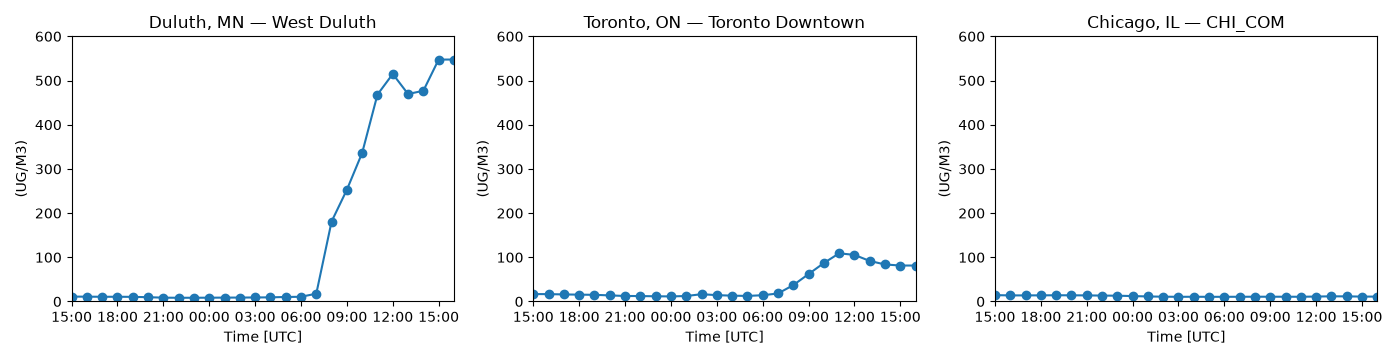

In [ ]:
cities = {
    "Duluth, MN":  ("-92.3,46.6,-91.9,47.0",    "West Duluth"),
    "Toronto, ON": ("-79.65,43.58,-79.25,43.85", "Toronto Downtown"),
    "Chicago, IL": ("-87.9,41.7,-87.5,42.05",    "CHI_COM"),
}

ds_cities = {}
for city, (bounds, site) in cities.items():
    ds = act.discovery.get_airnow_bounded_obs(
        token, START_DATE, END_DATE, bounds, "PM25", mon_type=2, data_type="B"
    )
    ds_cities[city] = ds.sel(sites=site)

tsd = act.plotting.TimeSeriesDisplay(ds_cities, subplot_shape=(1, 3), figsize=(14, 3.6))
for idx, (city, (_, site)) in enumerate(cities.items()):
    tsd.plot(
        "PM2.5", dsname=city, subplot_index=(0, idx),
        y_rng=(0, 600), force_line_plot=True, marker="o",
        set_title=f"{city} \u2014 {site}",
    )
tsd.fig.tight_layout()
plt.show()

## Summary

Using only `act.discovery.get_airnow_bounded_obs` for data access and ACT's `GeographicPlotDisplay` / `TimeSeriesDisplay` for visualization, we captured a cross-border smoke episode: PM$_{2.5}$ near Duluth reaching hazardous levels overnight, elevated values reaching into southern Ontario, and Chicago staying comparatively clean. The same pattern generalizes to any AirNow-covered region and date in the archive — change `map_bounds`, the city bounding boxes, and the date window.